In [1]:
import h5py
import xarray as xr
import imageio
import matplotlib.pyplot as plt
import os
import numpy as np
import tidy3d as td
import matplotlib
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from scipy.fft import fftn, ifftn, fftshift
from scipy.interpolate import interp1d
from scipy.signal import argrelextrema
import sys
import scipy
from scipy.ndimage import gaussian_filter1d
# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

tidy3dAPI = os.environ["API_TIDY3D_KEY"]
plt.rc('font', family='Arial')

In [3]:
# data = AM.read_hdf5_as_dict("./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90.h5")
data = AM.read_hdf5_as_dict("./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90_absorbers.h5")
data_ls = AM.read_hdf5_as_dict(r"../20251002_Ls_test/data/ls_values/20260608_ls_values_n_2p9.h5")

In [4]:
gap_data = AM.read_hdf5_as_dict(rf"../../20250630 MPB Bands analysis/Data/gap_data.hdf5")
gaps_ff_22_n_2p90=14.3/(gap_data["Circular"]["0.22"]["gap_edges"][np.where(gap_data["Circular"]["0.22"]["n"]==2.9)[0]]).flatten()

In [5]:
data.keys()

dict_keys(['2.90'])

In [6]:
a=2.562629142772549

In [7]:
def diameter(intensity_array,x,y):
    intensity = intensity_array
    integral_1 = scipy.integrate.simpson(scipy.integrate.simpson(intensity**2, x=y, axis=1), x=x, axis=0)
    integral_2 = scipy.integrate.simpson(scipy.integrate.simpson(intensity, x=y, axis=1), x=x, axis=0)**2
    
    return 2*np.sqrt((integral_2/integral_1)/np.pi)


def moving_average(x, w=3):
    if w <= 1:
        return x
    return np.convolve(x, np.ones(w), 'valid') / w

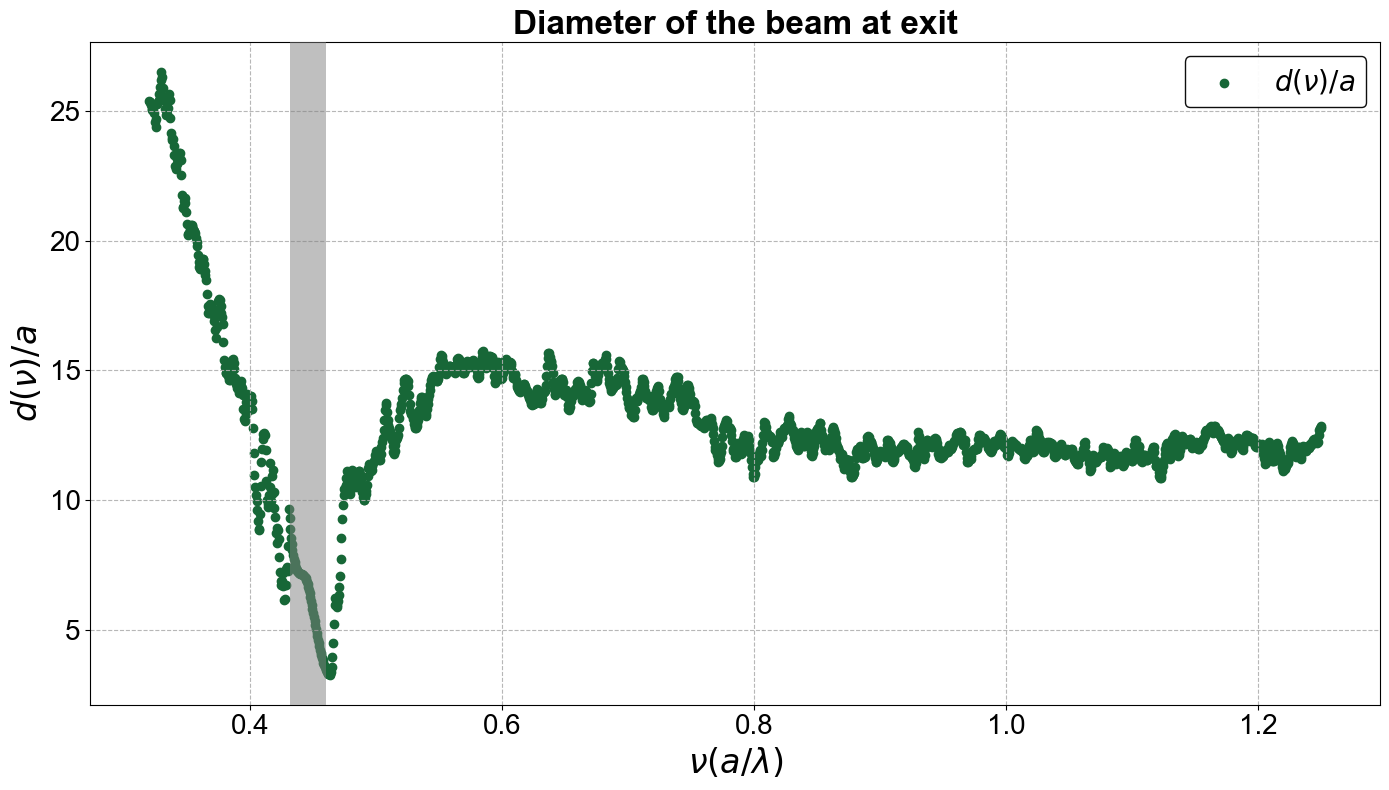

In [16]:
from scipy.optimize import curve_fit
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

for k,key in enumerate(data.keys()):
    intensity_values = ((np.abs(data[key]["Ex"])**2 + np.abs(data[key]["Ey"])**2 + np.abs(data[key]["Ez"])**2).squeeze())
    intensity_values = intensity_values/np.max(intensity_values)
    # intensity_values[intensity_values/np.max(intensity_values)<=1e-12]=0

    d = diameter(intensity_values,data[key]["x"],data[key]["y"])/a
    spread_smooth_nan_mask = ~np.isnan(d)
    freq = a*data[key]["f"]/(td.C_0)
    ax.scatter(freq,d,label=rf"$d(\nu)/a$")
    

ax.set_xlabel(rf"$\nu (a/\lambda)$", fontsize=24, fontweight='bold')
ax.set_ylabel(rf"$d(\nu)/a$", fontsize=24, fontweight='bold')
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=20, framealpha=0.95, edgecolor='black')

# ax.set_xlim(0.33,0.6)
# Improve tick label size
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_title(rf"Diameter of the beam at exit", fontsize=24, fontweight='bold')
ax.axvspan(a/gaps_ff_22_n_2p90[0], a/gaps_ff_22_n_2p90[1], facecolor='gray', alpha=0.5, edgecolor='none', zorder=1000, clip_on=False)

# Add subtle background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


In [17]:
freq.min(), freq.max()

(0.31999999999999995, 1.25)

## Expected spreading in a diffusive slab *without absorption*

We want a baseline that says: *if the light merely diffused (multiple scattering, no localization, no absorption), how wide would the transmitted beam be at each frequency?* Any measured width **below** that baseline is the fingerprint of (sub‑diffusive) transverse confinement / Anderson localization.

There are two equivalent ways to phrase the diffusion baseline, depending on whether you look at the **time‑resolved** or the **steady‑state** data.

### 1. Time‑resolved width (folder `20251007_Beam_Spreading` and the FFT notebook)
A pulse spreads transversely as a 2‑D random walk. Without absorption the transverse mean‑square width grows **linearly in time**:

$$ w^2(t) = w_0^2 + 4\,D\,t , \qquad D = \tfrac{1}{3}\,v_E\,\ell^{*} $$

with $D$ the Boltzmann diffusion constant, $v_E$ the energy (transport) velocity and $\ell^{*}$ the transport mean free path. Localization makes $w^2(t)$ grow **sub‑linearly and saturate** at $\sim\xi^2$ (the localization length). This is exactly the diagnostic of Sperling *et al.* and the $d(t)\!\propto\!\sqrt t$ fit already used in the time‑domain notebook. Implemented here as `diffusive_width_time(t, D)`.

> ⚠️ A finite absorption length also bends $w^2(t)$ downward and can *mimic* localization — this was the core of the Scheffold–Wiersma–Maret debate. Working **without absorption** (as in these simulations) removes that ambiguity, so a downward deviation is unambiguous.

### 2. Steady‑state width vs. frequency (**this notebook**, $d(\nu)$)
For CW excitation, the diffusion equation with $\mu_a=0$ is just Laplace's equation, so the **only** length scale is the slab thickness $L$. The spatially‑resolved transmittance $T(\rho)$ of a slab is obtained with the **extrapolated‑boundary image‑dipole** construction: an infinite set of source/sink pairs mirrored across the two planes $z=-z_e$ and $z=L+z_e$, with source depth $z_0=\ell^{*}$ and extrapolation length $z_e=\tfrac{2}{3}A\ell^{*}$ ($A=(1+R)/(1-R)$ for internal reflection $R$). The exit‑face flux is

$$ T(\rho)\;\propto\;\sum_{n}\Big[\frac{L-z_{+,n}}{(\rho^2+(L-z_{+,n})^2)^{3/2}}-\frac{L-z_{-,n}}{(\rho^2+(L-z_{-,n})^2)^{3/2}}\Big] $$

The resulting spot width is **thickness‑limited** ($\sim L$) and only weakly dependent on $\ell^{*}$ once $\ell^{*}\!\ll\!L$, so in normalised units the baseline is nearly **flat in $\nu$**. A genuine per‑frequency curve follows by feeding a measured $\ell^{*}(\nu)$ (and/or $A(\nu)$) — both drop near the band edges, lowering the diffusive baseline there too. Implemented as `slab_diffusion_intensity(...)` → `diffusive_diameter_slab(...)`, which feeds $T(\rho)$ through the **same** participation‑ratio `diameter()` estimator used on the field data so the two curves are directly comparable.

### How to get $\ell^{*}(\nu)$ and $v_E(\nu)$ to make the baseline truly per‑frequency
- $\ell^{*}(\nu)$: from the decay of the **coherent (ballistic) transmission** $T_{coh}\propto e^{-L/\ell}$, or from the total diffuse transmission via Ohm's law $T\simeq (\ell^{*}+z_e)/(L+2z_e)$.
- $v_E(\nu)$: from the dispersion / density of states of the structure (slow light near band edges → small $v_E$ → small $D$).
- Then $D(\nu)=\tfrac13 v_E(\nu)\,\ell^{*}(\nu)$ feeds the time‑resolved baseline, and $\ell^{*}(\nu)$ feeds the steady‑state one.

### References
1. **M. S. Patterson, B. Chance, B. C. Wilson**, *Time resolved reflectance and transmittance for the non‑invasive measurement of tissue optical properties*, **Appl. Opt. 28, 2331 (1989)** — slab diffusion solution by image dipoles.
2. **D. Contini, F. Martelli, G. Zaccanti**, *Photon migration through a turbid slab described by a model based on the diffusion approximation. I. Theory*, **Appl. Opt. 36, 4587 (1997)** — definitive slab CW & time‑resolved transmittance with extrapolated boundary conditions (the formula coded here).
3. **T. Sperling, W. Bührer, C. M. Aegerter, G. Maret**, *Direct determination of the transition to localization of light in three dimensions*, **Nat. Photon. 7, 48 (2013)** — transverse‑width growth $w^2=w_0^2+4Dt$ as the localization probe.
4. **C. M. Aegerter, G. Maret**, *Coherent backscattering and Anderson localization of light*, **Prog. Opt. 52, 1 (2009)** — review of time‑dependent diffusion / transverse spreading.
5. **F. Scheffold, R. Lenke, R. Tweer, G. Maret**, *Localization or classical diffusion of light?*, **Nature 398, 206 (1999)** — absorption can mimic the localization signature (motivates the no‑absorption baseline).
6. **M. P. van Albada, B. A. van Tiggelen, A. Lagendijk, A. Tip**, *Speed of propagation of classical waves in strongly scattering media*, **PRL 66, 3132 (1991)** — $D=\tfrac13 v_E\ell^{*}$ and the energy velocity.
7. **H. De Raedt, A. Lagendijk, P. de Vries**, *Transverse localization of light*, **PRL 62, 47 (1989)**; **T. Schwartz, G. Bartal, S. Fishman, M. Segev**, *Transport and Anderson localization in disordered two‑dimensional photonic lattices*, **Nature 446, 52 (2007)** — the transverse‑localization geometry (propagation axis ↔ time).


In [ ]:
# =====================================================================
#  Expected transverse spreading in a NON-ABSORBING diffusive slab
# =====================================================================
# Steady-state (CW) spatially-resolved transmittance T(rho) of a slab of
# thickness L in the diffusion approximation, built with the extrapolated-
# boundary image-dipole construction (Patterson 1989; Contini 1997). Absorption
# is set to zero (mu_a = 0), so the diffusion equation is Laplace's equation and
# the ONLY length scales are L and the transport mean free path l* (which enters
# through the source depth z0 = l* and the extrapolation length z_e = 2/3*A*l*).
# The diffuse spot width is therefore thickness-limited (~ L) and almost
# independent of l* once l* << L.
#
# The expected diffusive "diameter" is obtained by passing T(rho) through the
# SAME participation-ratio `diameter()` estimator used on the simulated field,
# so the two are directly comparable on the d(nu)/a plot. See the markdown cell
# above for the physics and the literature references.
from scipy.ndimage import gaussian_filter


def slab_diffusion_intensity(x, y, L, l_tr, A=1.0, n_terms=25, center=(0.0, 0.0)):
    """CW transverse intensity T(x, y) transmitted through a non-absorbing
    diffusive slab of thickness ``L`` (diffusion approximation, mu_a = 0).

    Image-dipole sum between the two extrapolated boundary planes located at
    z = -z_e and z = L + z_e (Patterson 1989; Contini 1997).

    Parameters
    ----------
    x, y    : 1D transverse coordinate arrays (same length units as L, l_tr).
    L       : slab thickness.
    l_tr    : transport mean free path l*.
    A       : internal-reflection factor of the boundary, A = (1+R)/(1-R)
              (A = 1 for an index-matched boundary; larger if the slab/cladding
              index step traps light, which widens z_e).
    n_terms : number of image-dipole pairs summed on each side (convergence).
    center  : (x0, y0) transverse position of the incident beam axis.

    Returns
    -------
    T : 2D array, axis 0 -> x, axis 1 -> y, clipped to >= 0 and peak-normalised.
    """
    X, Y = np.meshgrid(np.asarray(x, float), np.asarray(y, float), indexing="ij")
    rho2 = (X - center[0]) ** 2 + (Y - center[1]) ** 2

    z0 = l_tr                       # isotropic equivalent source one l* inside
    z_e = (2.0 / 3.0) * A * l_tr    # extrapolation length
    Lp = L + 2.0 * z_e              # separation of the extrapolated planes

    T = np.zeros_like(rho2)
    for n in range(-n_terms, n_terms + 1):
        z_plus = 2.0 * n * Lp + z0                  # positive image source
        z_minus = 2.0 * n * Lp - 2.0 * z_e - z0     # negative image (sink)
        dp = L - z_plus
        dm = L - z_minus
        Rp = np.sqrt(rho2 + dp * dp)
        Rm = np.sqrt(rho2 + dm * dm)
        T += dp / Rp ** 3 - dm / Rm ** 3            # exit-face flux of each pair
    T = np.clip(T, 0.0, None)
    peak = T.max()
    return T / peak if peak > 0 else T


def diffusive_diameter_slab(x, y, L, l_tr, a=a, A=1.0, n_terms=25,
                            beam_fwhm=None, center=(0.0, 0.0)):
    """Expected diffusive beam diameter d/a at the exit of a non-absorbing slab,
    measured with the SAME participation-ratio estimator as the simulated data.

    ``l_tr`` may be a scalar or a 1D array (one value per frequency); an array
    of the same length is returned in the latter case. ``beam_fwhm`` optionally
    blurs the point-source profile by the finite input-beam width (Gaussian).
    """
    l_arr = np.atleast_1d(l_tr).astype(float)
    out = np.empty(l_arr.size)
    dx = float(np.mean(np.diff(np.asarray(x, float))))
    for i, lt in enumerate(l_arr):
        T = slab_diffusion_intensity(x, y, L, lt, A=A, n_terms=n_terms, center=center)
        if beam_fwhm:
            T = gaussian_filter(T, (beam_fwhm / 2.3548) / abs(dx))
        out[i] = diameter(T, x, y) / a
    return out[0] if out.size == 1 else out


def diffusion_constant(l_tr, v_E):
    """Boltzmann transport diffusion constant D = v_E * l* / 3 (3D)."""
    return v_E * l_tr / 3.0


def diffusive_width_time(t, D, w0=0.0):
    """Time-resolved diffusive transverse RMS-width growth, no absorption,
    2D transverse plane:   w(t) = sqrt(w0**2 + 4 * D * t).

    This is the benchmark for the time-domain notebooks (folder
    20251007_Beam_Spreading and 20260602_IPR_Calculation_FFT). A measured width
    that grows slower than sqrt(4 D t) -- or saturates -- is the localization
    signature (Sperling 2013; Aegerter & Maret 2009). NOTE: residual absorption
    also bends w(t) downward and can masquerade as localization, which is why an
    absorption-free benchmark matters (Scheffold 1999).
    """
    return np.sqrt(w0 ** 2 + 4.0 * D * t)


In [ ]:
# --- Overlay the diffusive (no-absorption) benchmark on the measured d(nu) ---
# For l* << L the steady-state width is set by the slab thickness L, so the
# benchmark is almost flat in nu (the three l* lines nearly coincide). The
# measured d(nu) dropping BELOW this band -- e.g. inside the gap (grey) -- is the
# signature of (sub-diffusive) confinement / localization that diffusion alone
# cannot produce. To turn the benchmark into a genuine per-frequency curve,
# pass a measured l*(nu) array as `l_tr`.

L_slab = 14.3          # slab thickness in um  (= t_slab_z of the run, box_size*scaling)

fig, ax = plt.subplots(figsize=(14, 8), dpi=100)
x_ = y_ = None
for key in data.keys():
    I = (np.abs(data[key]["Ex"])**2 + np.abs(data[key]["Ey"])**2 + np.abs(data[key]["Ez"])**2).squeeze()
    I = I / np.max(I)
    d = diameter(I, data[key]["x"], data[key]["y"]) / a
    freq = a * data[key]["f"] / td.C_0
    ax.scatter(freq, d, s=14, zorder=5, label=r"simulated $d(\nu)/a$")
    x_, y_ = data[key]["x"], data[key]["y"]

# diffusive (no-absorption) prediction for a few transport mean free paths l*/a
for ltr_over_a in [0.5, 1.0, 2.0]:
    d_diff = diffusive_diameter_slab(x_, y_, L_slab, ltr_over_a * a)
    ax.axhline(d_diff, ls="--", lw=2,
               label=rf"diffusion (no abs.), $\ell^*={ltr_over_a:.1f}a \to d/a={d_diff:.1f}$")

ax.axvspan(a / gaps_ff_22_n_2p90[0], a / gaps_ff_22_n_2p90[1],
           facecolor='gray', alpha=0.4, edgecolor='none', zorder=0, label="band gap")
ax.set_xlabel(r"$\nu\,(a/\lambda)$", fontsize=24, fontweight='bold')
ax.set_ylabel(r"$d/a$", fontsize=24, fontweight='bold')
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=13, framealpha=0.95, edgecolor='black')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_title("Measured vs diffusive (no-absorption) spreading", fontsize=22, fontweight='bold')
ax.set_facecolor('white'); fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()
